# Text Preprocessing - Support Ticket Classification

This notebook performs comprehensive text preprocessing:
- Text cleaning (lowercasing, punctuation removal)
- Stopword removal
- Lemmatization
- Priority label creation
- Save processed data for modeling

In [1]:
# Import libraries
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
from src.preprocessing import (
    clean_text, 
    preprocess_dataframe, 
    create_priority_labels,
    download_nltk_data
)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dharn\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\dharn\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 1. Load Data

In [2]:
# Load exploration summary to get column names
try:
    summary = pd.read_csv('../data/processed/exploration_summary.csv')
    text_col = summary['text_column'].values[0]
    category_col = summary['category_column'].values[0]
    print(f"✓ Using text column: {text_col}")
    print(f"✓ Using category column: {category_col}")
except:
    print("⚠️ Exploration summary not found. Please run 01_data_exploration.ipynb first.")
    text_col = None
    category_col = None

✓ Using text column: Ticket Description
✓ Using category column: Ticket Type


In [3]:
# Load dataset
data_path = '../data/tickets.csv'  # Adjust filename as needed

df = pd.read_csv(data_path)
print(f"✓ Loaded {len(df):,} tickets")
print(f"  Columns: {list(df.columns)}")

# If columns not detected, manually set them
if text_col is None or pd.isna(text_col):
    print("\n⚠️ Please manually set the text column:")
    print("Available columns:", list(df.columns))
    # text_col = 'your_text_column_name'  # Uncomment and set

if category_col is None or pd.isna(category_col):
    print("\n⚠️ Please manually set the category column:")
    print("Available columns:", list(df.columns))
    # category_col = 'your_category_column_name'  # Uncomment and set

✓ Loaded 8,469 tickets
  Columns: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [4]:
# Display sample data
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## 2. Text Cleaning Examples

In [5]:
# Test cleaning function on sample texts
sample_texts = [
    "URGENT!!! My account is LOCKED and I cannot login. Please help ASAP!!!",
    "How do I reset my password? I forgot it.",
    "Billing question: Why was I charged $99.99 on 01/15/2024?"
]

print("Text Cleaning Examples:")
print("="*80)

for i, text in enumerate(sample_texts, 1):
    cleaned = clean_text(text)
    print(f"\n{i}. ORIGINAL:")
    print(f"   {text}")
    print(f"   CLEANED:")
    print(f"   {cleaned}")
    print("-"*80)

Text Cleaning Examples:

1. ORIGINAL:
   URGENT!!! My account is LOCKED and I cannot login. Please help ASAP!!!
   CLEANED:
   urgent account locked login please help asap
--------------------------------------------------------------------------------

2. ORIGINAL:
   How do I reset my password? I forgot it.
   CLEANED:
   reset password forgot
--------------------------------------------------------------------------------

3. ORIGINAL:
   Billing question: Why was I charged $99.99 on 01/15/2024?
   CLEANED:
   billing question charged
--------------------------------------------------------------------------------


## 3. Preprocess All Tickets

In [6]:
# Ensure NLTK data is downloaded
download_nltk_data()
print("✓ NLTK data ready")

✓ NLTK data ready


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dharn\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\dharn\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [7]:
# Preprocess the dataset
if text_col:
    print(f"\nPreprocessing {len(df):,} tickets...")
    print("This may take a few minutes...\n")
    
    df_processed = preprocess_dataframe(
        df, 
        text_column=text_col,
        remove_stopwords=True,
        lemmatize=True
    )
    
    print(f"\n✓ Preprocessing complete!")
    print(f"  Original tickets: {len(df):,}")
    print(f"  After cleaning: {len(df_processed):,}")
    print(f"  Removed: {len(df) - len(df_processed):,} empty tickets")
else:
    print("❌ Text column not set. Please set text_col variable.")


Preprocessing 8,469 tickets...
This may take a few minutes...

Preprocessing 8469 tickets...
✓ Preprocessing complete: 8469 tickets remaining

✓ Preprocessing complete!
  Original tickets: 8,469
  After cleaning: 8,469
  Removed: 0 empty tickets


In [8]:
# Compare original vs cleaned text
if text_col:
    print("Sample Comparisons:")
    print("="*80)
    
    for i in range(min(5, len(df_processed))):
        print(f"\n{i+1}. ORIGINAL:")
        print(f"   {df_processed.iloc[i][text_col][:150]}...")
        print(f"   CLEANED:")
        print(f"   {df_processed.iloc[i][f'{text_col}_cleaned'][:150]}...")
        print("-"*80)

Sample Comparisons:

1. ORIGINAL:
   I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website ad...
   CLEANED:
   im issue productpurchased please assist billing zip code appreciate requested website address please double check email address ive tried troubleshoot...
--------------------------------------------------------------------------------

2. ORIGINAL:
   I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_pu...
   CLEANED:
   im issue productpurchased please assist need change existing product im issue productpurchased please assist issue im facing intermittent sometimes wo...
--------------------------------------------------------------------------------

3. ORIGINAL:
   I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until ye

## 4. Text Length Analysis (After Cleaning)

In [9]:
# Calculate text statistics after cleaning
if text_col:
    cleaned_col = f'{text_col}_cleaned'
    
    df_processed['cleaned_length'] = df_processed[cleaned_col].str.len()
    df_processed['cleaned_word_count'] = df_processed[cleaned_col].str.split().str.len()
    
    print("Text Statistics After Cleaning:")
    print("="*60)
    print(f"Average text length: {df_processed['cleaned_length'].mean():.2f} characters")
    print(f"Average word count: {df_processed['cleaned_word_count'].mean():.2f} words")
    print(f"Min word count: {df_processed['cleaned_word_count'].min()}")
    print(f"Max word count: {df_processed['cleaned_word_count'].max()}")

Text Statistics After Cleaning:
Average text length: 186.05 characters
Average word count: 24.57 words
Min word count: 12
Max word count: 46


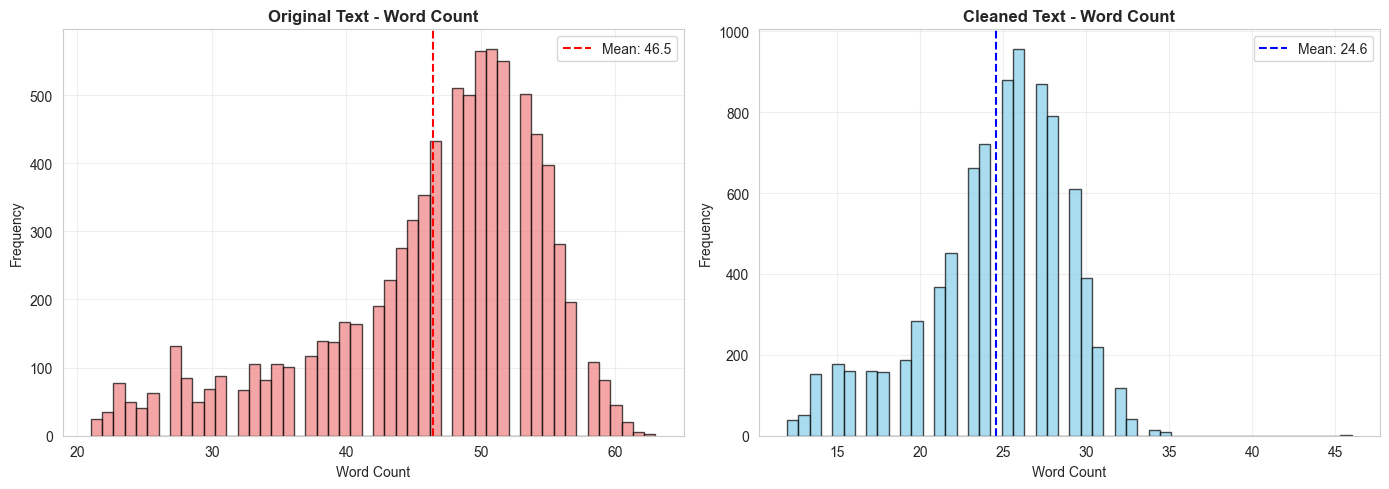

✓ Plot saved to: outputs/preprocessing_comparison.png


In [10]:
# Visualize before/after comparison
if text_col:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Original text length
    original_lengths = df[text_col].astype(str).str.split().str.len()
    axes[0].hist(original_lengths, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
    axes[0].set_title('Original Text - Word Count', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Word Count')
    axes[0].set_ylabel('Frequency')
    axes[0].axvline(original_lengths.mean(), color='red', linestyle='--', 
                    label=f'Mean: {original_lengths.mean():.1f}')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Cleaned text length
    axes[1].hist(df_processed['cleaned_word_count'], bins=50, color='skyblue', 
                 edgecolor='black', alpha=0.7)
    axes[1].set_title('Cleaned Text - Word Count', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Word Count')
    axes[1].set_ylabel('Frequency')
    axes[1].axvline(df_processed['cleaned_word_count'].mean(), color='blue', 
                    linestyle='--', label=f'Mean: {df_processed["cleaned_word_count"].mean():.1f}')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../outputs/preprocessing_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Plot saved to: outputs/preprocessing_comparison.png")

## 5. Create Priority Labels

In [11]:
# Create priority labels based on ticket characteristics
if text_col:
    print("Creating priority labels...\n")
    
    # Custom urgency keywords
    urgency_keywords = [
        'urgent', 'critical', 'emergency', 'asap', 'immediately',
        'down', 'outage', 'not working', 'broken', 'failed',
        'security', 'breach', 'hack', 'virus', 'malware',
        'cannot access', 'locked out', 'error', 'crash'
    ]
    
    df_processed = create_priority_labels(
        df_processed,
        category_column=category_col if category_col and not pd.isna(category_col) else None,
        urgency_keywords=urgency_keywords
    )
    
    print("\n✓ Priority labels created!")

Creating priority labels...


Priority Distribution:
priority
Low    8469
Name: count, dtype: int64

✓ Priority labels created!


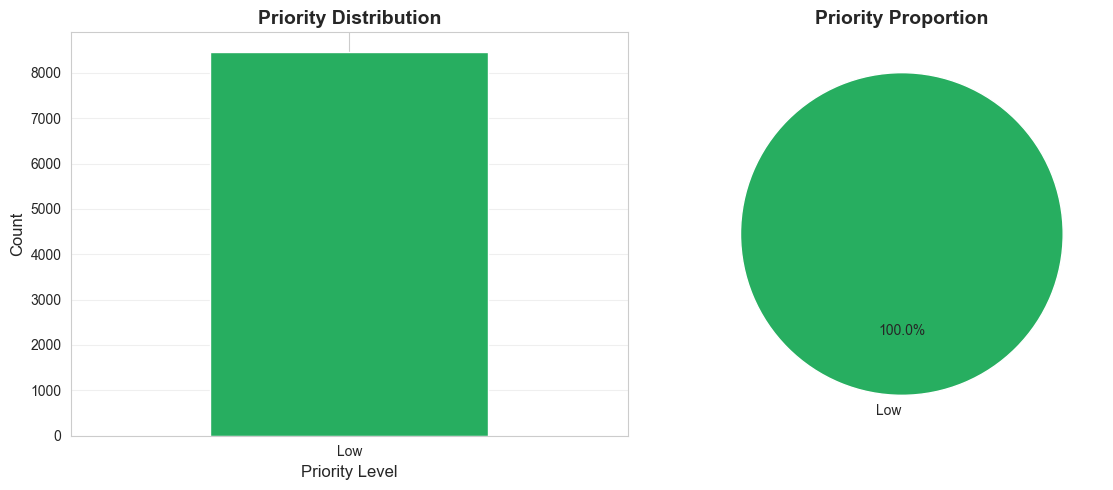

✓ Plot saved to: outputs/priority_distribution.png


In [12]:
# Visualize priority distribution
plt.figure(figsize=(12, 5))

# Count plot
plt.subplot(1, 2, 1)
priority_counts = df_processed['priority'].value_counts()
colors = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#27ae60'}
priority_counts.plot(kind='bar', color=[colors.get(x, 'gray') for x in priority_counts.index])
plt.title('Priority Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Priority Level', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Pie chart
plt.subplot(1, 2, 2)
priority_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90,
                     colors=[colors.get(x, 'gray') for x in priority_counts.index])
plt.title('Priority Proportion', fontsize=14, fontweight='bold')
plt.ylabel('')

plt.tight_layout()
plt.savefig('../outputs/priority_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved to: outputs/priority_distribution.png")

<Figure size 1200x600 with 0 Axes>

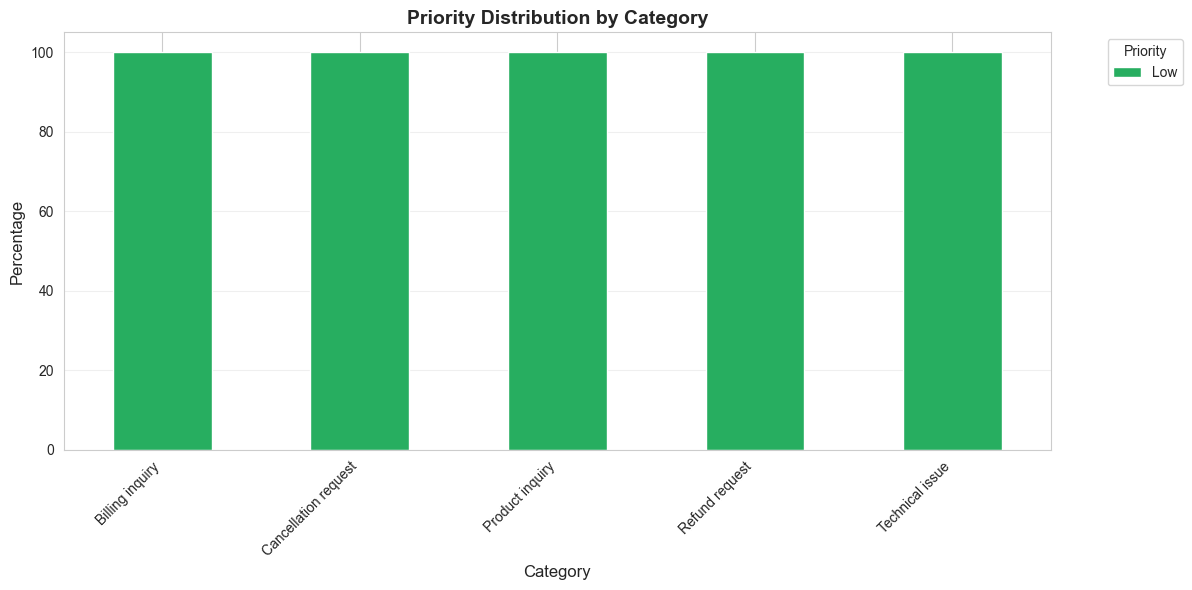

✓ Plot saved to: outputs/priority_by_category.png


In [13]:
# Priority by category (if category column exists)
if category_col and not pd.isna(category_col):
    priority_by_category = pd.crosstab(
        df_processed[category_col], 
        df_processed['priority'],
        normalize='index'
    ) * 100
    
    plt.figure(figsize=(12, 6))
    priority_by_category.plot(kind='bar', stacked=True, 
                              color=['#27ae60', '#f39c12', '#e74c3c'])
    plt.title('Priority Distribution by Category', fontsize=14, fontweight='bold')
    plt.xlabel('Category', fontsize=12)
    plt.ylabel('Percentage', fontsize=12)
    plt.legend(title='Priority', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../outputs/priority_by_category.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Plot saved to: outputs/priority_by_category.png")

## 6. Sample Priority Examples

In [14]:
# Show examples of each priority level
if text_col:
    cleaned_col = f'{text_col}_cleaned'
    
    print("Sample Tickets by Priority:")
    print("="*80)
    
    for priority in ['High', 'Medium', 'Low']:
        print(f"\n{priority.upper()} PRIORITY:")
        print("-"*80)
        
        samples = df_processed[df_processed['priority'] == priority][cleaned_col].head(3)
        for i, text in enumerate(samples, 1):
            print(f"  {i}. {text[:150]}...")
            print()

Sample Tickets by Priority:

HIGH PRIORITY:
--------------------------------------------------------------------------------

MEDIUM PRIORITY:
--------------------------------------------------------------------------------

LOW PRIORITY:
--------------------------------------------------------------------------------
  1. im issue productpurchased please assist billing zip code appreciate requested website address please double check email address ive tried troubleshoot...

  2. im issue productpurchased please assist need change existing product im issue productpurchased please assist issue im facing intermittent sometimes wo...

  3. im facing problem productpurchased productpurchased turning working fine yesterday doesnt respond really im using original charger came productpurchas...



## 7. Save Processed Data

In [15]:
# Save processed dataset
output_path = '../data/processed/tickets_processed.csv'
df_processed.to_csv(output_path, index=False)

print(f"✓ Processed data saved to: {output_path}")
print(f"  Total records: {len(df_processed):,}")
print(f"  Columns: {list(df_processed.columns)}")

✓ Processed data saved to: ../data/processed/tickets_processed.csv
  Total records: 8,469
  Columns: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating', 'Ticket Description_cleaned', 'cleaned_length', 'cleaned_word_count', 'priority']


In [16]:
# Save preprocessing metadata
metadata = {
    'original_records': len(df),
    'processed_records': len(df_processed),
    'removed_records': len(df) - len(df_processed),
    'text_column': text_col,
    'category_column': category_col,
    'cleaned_column': f'{text_col}_cleaned' if text_col else None,
    'priority_high': (df_processed['priority'] == 'High').sum(),
    'priority_medium': (df_processed['priority'] == 'Medium').sum(),
    'priority_low': (df_processed['priority'] == 'Low').sum()
}

metadata_df = pd.DataFrame([metadata])
metadata_df.to_csv('../data/processed/preprocessing_metadata.csv', index=False)

print("\n✓ Preprocessing metadata saved")
print("\nPreprocessing Summary:")
print("="*60)
for key, value in metadata.items():
    print(f"  {key}: {value}")


✓ Preprocessing metadata saved

Preprocessing Summary:
  original_records: 8469
  processed_records: 8469
  removed_records: 0
  text_column: Ticket Description
  category_column: Ticket Type
  cleaned_column: Ticket Description_cleaned
  priority_high: 0
  priority_medium: 0
  priority_low: 8469
